In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_column',None)
from sklearn.model_selection import train_test_split,GridSearchCV 
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
import pickle

## Load dữ liệu

In [16]:
data = pd.read_csv('C:\\Users\\BSS GROUP\\DATN_1\\Data_diabetes.csv', low_memory=False, encoding='latin-1')
data

,V1,Tinh/Thanhpho,Quan/huyen,Xa/phuong,Ngay phong van,Ho ten,id,Dia chi,Gioi,Nam sinh,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Nam chuan doan tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,GÐ_CNB_ÐTÐ,Bo/Me_MÐTÐ,Anh/chi/em MDTÐ,Ong/ba noi MÐTÐ,Con_MÐTÐ,tien_xu_benh _tim_mach,dot_quy,Dau_that_nguc,Suy_tim,loet_ban_chan,cat_cut_chi,roi_loan_mo_mau,roi_loan_mo_mau_nam,kg_luc_nang_nhat,tuoi_luc_nang_nhat,da_mang_thai_chua,co_bi_tieu_duong_thai_ki_khong,xet_nghiem_duong_mau_luc_doi,xet_nghiem_duong_mau_sau_2h,year,Nhomtuoi,chieucao_mean,cannang_mean,vongeo_mean,vonghong_mean,HATT_mean,HATTr_mean,BMI,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_male,WHR_female,WHR_class,Diabetes,Pre_diabete,Glucose_class,std_wgt1,cvd,obesity,khuvuc,khuvuc2,WHR_male2,WHR_female2,WHR_total,glucose,prediabetes2,std_wgt3,tccv,glucose2,fpg,dia,predia,fpgva
0,1785,32,1,4,40717.0,DANG THI THU HA,34.0,"TO 1, THACH THANG",2,1950,1,2,5,11,1,2009,2.0,2.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,54,61,1.0,2.0,"5,6","6,8",2011,4,150,54,70,85,120,70,24,3,0,0.0,0.823529411764706,NaN,3.0,3,0,1.0,1,0.108646,0,0,2,2,NaN,1.0,1,1,1,0.119252,0,1,1,0,1,0
1,1565,32,1,1,40733.0,LE THI THANH HUYEN,64.0,"TO 24, THANH BINH",2,1944,1,2,4,12,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,62,66,1.0,2.0,"7,8","16,4",2011,5,"146,05",60,94,102,120,80,28.1286006806418,4,1,1.0,0.92156862745098,NaN,4.0,4,1,NaN,2,0.108646,0,1,2,2,NaN,1.0,1,2,0,0.095826,0,2,2,1,0,0
2,460,32,1,3,40726.0,HA THUC HAI,210.0,"TO 36, BINH HIEN",1,1954,1,2,5,10,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,81,55,2.0,NaN,"5,7","6,1",2011,3,169,81,101,104,140,80,28.3603515283078,4,1,2.0,0.971153846153846,3.0,NaN,3,0,1.0,1,0.178560,0,1,2,2,1.0,NaN,1,1,1,0.183041,0,1,1,0,1,0
3,1990,32,1,4,40721.0,HO THI GIAO,241.0,"TO 30, THACH THANG",2,1942,1,2,4,12,1,2008,2.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,1.0,2.0,2.0,2.0,2,2009,69,69,1.0,2.0,"6,6","10,2",2011,5,152,69,94,107,120,80,29.8649584487535,4,1,1.0,0.878504672897196,NaN,4.0,4,0,1.0,1,0.108646,1,1,2,2,NaN,1.0,1,1,1,0.095826,0,1,1,0,1,0
4,978,32,2,3,40731.0,NGUYEN VAN VIEN,228.0,"TO 35, HOA KHE",1,1965,1,2,3,11,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,1.0,2.0,2.0,1,9999,53,50,2.0,NaN,"6,2","7,6",2011,1,153,52,75,96,"110,5",70,22.2136784997223,2,0,0.0,"0,78125",1.0,NaN,1,0,1.0,1,0.223166,1,0,2,2,0.0,NaN,0,1,1,0.329838,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12720,13166,32,2,1,NaN,TRAN THI EM,243.0,T21,2,1953,1,2,5,10,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,55,30,1.0,3.0,"5,3",9999,2017,4,154,50,84,88,110,70,21.0828132906055,2,1,NaN,0.954545454545455,NaN,4.0,4,0,NaN,0,0.108646,0,0,2,2,NaN,1.0,1,0,0,0.119252,0,0,0,0,0,0
12721,12600,32,5,1,NaN,TRAN DAN CHINH,159.0,T21,1,1954,1,2,6,12,2,9999,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,1.0,2.0,2.0,1,9999,58,26,NaN,NaN,"4,7",9999,2017,4,159,47,66,82,120,70,18.5910367469641,2,0,1.0,0.804878048780488,1.0,NaN,1,0,NaN,0,0.108646,1,0,3,1,0.0,NaN,0,0,0,0.119252,0,0,0,0,0,0
12722,13107,32,2,2,42954.0,PHAM THI HA THANH,297.0,T101,2,1958,1,1,4,11,1,2005,2.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,60,57,1.0,3.0,"7,3",8,2017,3,150,60,84,97,110,70,26.6666666666667,4,1,NaN,0.865979381443299,NaN,4.0,4,1,NaN,2,0.178560,0,1,2,2,NaN,1.0,1,2,0,0.183041,0,2,2,1,0,0
12723,12832,32,2,2,42954.0,LUONG THI YEN,295.0,T53,2,1964,1,1,3,12,1,2010,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1,9999,58,52,NaN,3.0,"6,4","9,2",2017,2,151,58,86,99,185,100,25.4374808122451,4,1,3.0,0.868686868686869,NaN,4.0,4,0,

In [17]:
# Tạo cột Tuổi dựa vào năm thu thập
YEAR_COLLECTED = 2022

data['Tuoi'] = YEAR_COLLECTED - data['Nam sinh']

# Xóa cột Năm sinh để tránh đa cộng tuyến
data = data.drop(columns=['Nam sinh'])

### Nhận xét

- Dữ liệu đã được nạp thành công từ file CSV và hiển thị đầy đủ các cột.
- Sau khi tạo biến `Tuoi = 2022 - Nam sinh`, cột `Nam sinh` đã được loại bỏ để tránh trùng thông tin.
- Kết quả của bước này là bộ dữ liệu đầu vào đã sẵn sàng cho khâu làm sạch ở Bước 2.

## Bước 2: Xử lý dữ liệu
---

### Quan sát và khám phá tập dữ liệu
---

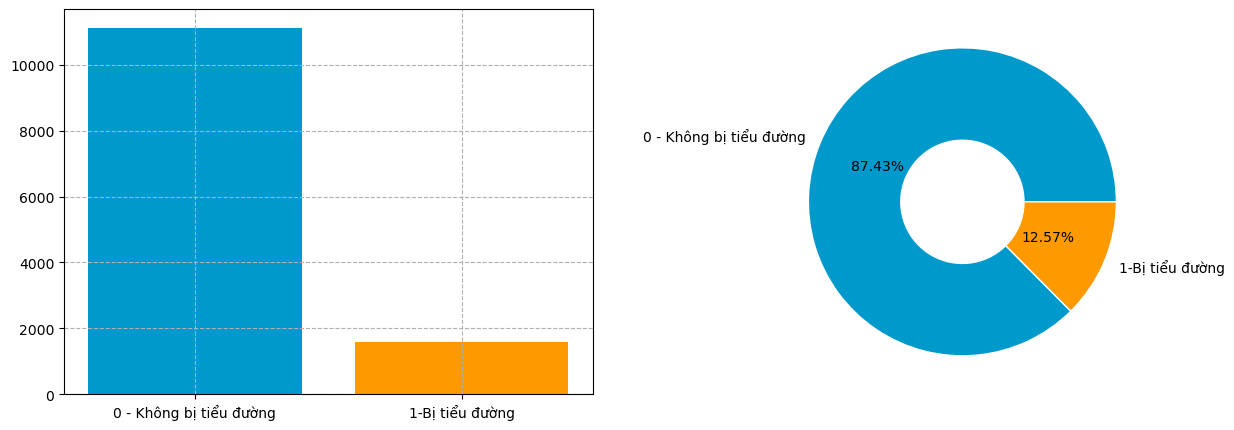

In [18]:
#Thống kê số lượng bệnh nhân bị bệnh và không bị bệnh (Đánh giá mức độ cân bằng dữ liệu)
kq = data['Diabetes'].value_counts()
lb = ['0 - Không bị tiểu đường','1-Bị tiểu đường']

#----------------------------------------------
#trực quan hóa số liệu
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))

#Vẽ biểu đồ cột thể hiện số lượng hồ sơ bị bệnh - không bị bệnh
plt.subplot(1,2,1) 
plt.bar(lb,kq.values, color=['#0099CC','#FF9900'])
plt.grid(ls='--')

#Vẽ biểu đồ tròn thể hiện tỷ lệ % hồ sơ bị bệnh - ko bị bệnh
plt.subplot(1,2,2)
plt.pie(kq.values, labels=lb, colors=['#0099CC','#FF9900'],
        autopct='%.2f%%', wedgeprops=dict(width=0.6,edgecolor='w'))

plt.show()

### Nhận xét

- Biểu đồ cho thấy lớp 0 và lớp 1 không cân bằng, nên cần ưu tiên metric Recall khi đánh giá.
- Đây là tín hiệu sớm để áp dụng `class_weight` hoặc tuning threshold ở giai đoạn mô hình.

### Loại bỏ các giá trị trùng lặp (Duplicates)

In [19]:
# Kiểm tra các giá trị trùng lăp
# In ra tổng các hàng trong dữ liệu
print('Tổng số hàng:', data.shape[0])
print('Các giá trị trùng lăp:', data.duplicated().sum())

Tổng số hàng: 12725
Các giá trị trùng lăp: 0


### Nhận xét

- Kết quả kiểm tra trùng lặp giúp xác nhận có cần loại bản ghi trùng trước khi train.
- Nếu số lượng trùng > 0, nên xử lý ngay để tránh làm lệch phân phối dữ liệu.

### Phát hiện và xử lý dữ liệu thiếu trong Dataset
---

In [20]:
#Kiểm tra dữ liệu thiếu trong Dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 75 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   V1                                      12725 non-null  int64  
 1   Tinh/Thanhpho                           12725 non-null  int64  
 2   Quan/huyen                              12725 non-null  int64  
 3   Xa/phuong                               12725 non-null  int64  
 4   Ngay phong van                          12231 non-null  float64
 5   Ho ten                                  12725 non-null  object 
 6   id                                      12723 non-null  float64
 7   Dia chi                                 12724 non-null  object 
 8   Gioi                                    12725 non-null  int64  
 9   Dan toc                                 12725 non-null  int64  
 10  Tinh chat cong viec                     12725 non-null  in

### Nhận xét

- `data.info()` cho thấy cột nào thiếu dữ liệu và kiểu dữ liệu thực tế của từng biến.
- Đây là cơ sở để chọn chiến lược điền thiếu theo từng nhóm cột ở cell kế tiếp.

In [21]:
# NHÓM 1: Cột liên quan đến điều trị tăng huyết áp (~75% missing)
# Lý do: Chỉ được hỏi khi bệnh nhân CÓ tiền sử THA
# → NaN = "Không áp dụng" → Điền 0
cols_tha = [
    'DT_THA_DY',
    'DT_THA_TY',
    'Bang an uong va luyen tap',
    'Da dieu tri tang huyet ap bao gio chua'
]
data[cols_tha] = data[cols_tha].fillna(0)
# NHÓM 2: Cột tiền sử biến chứng & gia đình (~25% missing)
# CẢI TIẾN: Tạo cột flag đánh dấu missing thay vì chỉ điền mode
# Giúp mô hình phân biệt "không bị" vs "không có thông tin"
cols_mode = [
    'dot_quy', 'Suy_tim', 'loet_ban_chan', 'cat_cut_chi',
    'Dau_that_nguc', 'Ong/ba noi MÐTÐ', 'Con_MÐTÐ',
    'Anh/chi/em MDTÐ', 'Bo/Me_MÐTÐ'
]
for col in cols_mode:
    # Tạo cột flag: 1 = missing, 0 = có thông tin
    data[f'{col}_missing'] = data[col].isna().astype(int)
    # Điền mode cho giá trị missing
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)
# NHÓM 3: Cột mang thai (~25-34% missing)
# NaN = "Không áp dụng" (nam) → Điền 0
data['da_mang_thai_chua'] = data['da_mang_thai_chua'].fillna(0)
data['co_bi_tieu_duong_thai_ki_khong'] = data['co_bi_tieu_duong_thai_ki_khong'].fillna(0)
# Cột phân loại huyết áp (~30% missing)
# Dùng MEDIAN để tránh ảnh hưởng outlier
median_val = data['Hypertension_class'].median()
data['Hypertension_class'] = data['Hypertension_class'].fillna(median_val)
# NHÓM 4: Cột missing rất ít (<1%) → Xóa hàng
rows_before = len(data)
data = data.dropna(subset=['GÐ_CNB_ÐTÐ', 'tien_xu_benh _tim_mach'])
rows_after = len(data)
# KIỂM TRA KẾT QUẢ
remaining_missing = data.isnull().sum().sum()
print(f"Tổng missing còn lại : {remaining_missing}")
print(f"Shape sau xử lý      : {data.shape}")
print(f"Số hàng đã xóa       : {rows_before - rows_after}")

Tổng missing còn lại : 34057
Shape sau xử lý      : (12703, 84)
Số hàng đã xóa       : 22


### Nhận xét

- Sau xử lý missing, tổng số giá trị thiếu giảm mạnh và dữ liệu ổn định hơn cho mô hình.
- Cách điền thiếu theo ngữ nghĩa từng nhóm cột hợp lý hơn điền đồng loạt một kiểu.

### Kiểm tra tính đồng nhất của dữ liệu
---

In [22]:
# Kiểm tra tính đồng nhất của các cột
unique_counts = data.nunique()
print(unique_counts)

V1                         12703
Tinh/Thanhpho                  4
Quan/huyen                     5
Xa/phuong                      9
Ngay phong van               177
                           ...  
Dau_that_nguc_missing          2
Ong/ba noi MÐTÐ_missing        2
Con_MÐTÐ_missing               2
Anh/chi/em MDTÐ_missing        2
Bo/Me_MÐTÐ_missing             2
Length: 84, dtype: int64


### Nhận xét

- Kiểm tra số giá trị phân biệt giúp phát hiện cột hằng, cột nhiễu hoặc cột cần mã hóa lại.
- Các cột có độ đa dạng thấp thường ít giá trị dự báo và cần xem xét khi chọn đặc trưng.

### Xóa các cột không có giá trị

In [23]:
drop_cols = [
 # glucose duplicate
 'glucose2','fpgva',

 # WHR duplicate
 'WHR_male','WHR_female','WHR_male2','WHR_female2','WHR_total',

 # obesity duplicate
 'obesity',

 # khu vực
 'khuvuc2',

 # tim mạch
 'cvd',

 # huyết áp
 'Nam chuan doan tang huyet ap',

 # cân nặng chuẩn
 'std_wgt1','std_wgt3',

 # text
 'Ho ten','Dia chi','Ngay phong van','Tinh/Thanhpho', 'Quan/huyen', 'Xa/phuong',

 # id
 'V1','id'
]

In [24]:
# Xóa các cột
data = data.drop(columns=drop_cols)

# In danh sách cột mới
print("Danh sách cột sau khi xóa:")
print(data.columns.tolist())

Danh sách cột sau khi xóa:
['Gioi', 'Dan toc', 'Tinh chat cong viec', 'Trinh do van hoa', 'Thoi gian an cach bua toi', 'Tien xu bi tang huyet ap', 'Da dieu tri tang huyet ap bao gio chua', 'Bang an uong va luyen tap', 'DT_THA_DY', 'DT_THA_TY', 'GÐ_CNB_ÐTÐ', 'Bo/Me_MÐTÐ', 'Anh/chi/em MDTÐ', 'Ong/ba noi MÐTÐ', 'Con_MÐTÐ', 'tien_xu_benh _tim_mach', 'dot_quy', 'Dau_that_nguc', 'Suy_tim', 'loet_ban_chan', 'cat_cut_chi', 'roi_loan_mo_mau', 'roi_loan_mo_mau_nam', 'kg_luc_nang_nhat', 'tuoi_luc_nang_nhat', 'da_mang_thai_chua', 'co_bi_tieu_duong_thai_ki_khong', 'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h', 'year', 'Nhomtuoi', 'chieucao_mean', 'cannang_mean', 'vongeo_mean', 'vonghong_mean', 'HATT_mean', 'HATTr_mean', 'BMI', 'BMI_class', 'Abdominal_Obese', 'Hypertension_class', 'WHR', 'WHR_class', 'Diabetes', 'Pre_diabete', 'Glucose_class', 'khuvuc', 'glucose', 'prediabetes2', 'tccv', 'fpg', 'dia', 'predia', 'Tuoi', 'dot_quy_missing', 'Suy_tim_missing', 'loet_ban_chan_missing', 'c

### Nhận xét

- Danh sách cột sau khi xóa giúp xác nhận các cột trùng ý nghĩa và cột không cần thiết đã được loại bỏ.
- Bước này làm dữ liệu gọn hơn, giảm nhiễu trước khi chuyển kiểu và tạo feature.

### Check lại dữ liệu sau khi xóa

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12703 entries, 0 to 12724
Data columns (total 63 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gioi                                    12703 non-null  int64  
 1   Dan toc                                 12703 non-null  int64  
 2   Tinh chat cong viec                     12703 non-null  int64  
 3   Trinh do van hoa                        12703 non-null  int64  
 4   Thoi gian an cach bua toi               12703 non-null  int64  
 5   Tien xu bi tang huyet ap                12703 non-null  int64  
 6   Da dieu tri tang huyet ap bao gio chua  12703 non-null  float64
 7   Bang an uong va luyen tap               12703 non-null  float64
 8   DT_THA_DY                               12703 non-null  float64
 9   DT_THA_TY                               12703 non-null  float64
 10  GÐ_CNB_ÐTÐ                              12703 non-null  float64

In [26]:
# CHUYỂN ĐỔI CÁC CỘT OBJECT SANG KIỂU SỐ
import re
# --- Xử lý riêng 2 cột xét nghiệm đường máu (có chứa text/ký tự đặc biệt) ---
blood_sugar_cols = ['xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h']
for col in blood_sugar_cols:
    # Bước 1: Chuyển sang chuỗi
    data[col] = data[col].astype(str)
    # Bước 2: Thay dấu phẩy thành dấu chấm (format số VN → Python)
    data[col] = data[col].str.replace(',', '.')
    # Bước 3: Dùng Regex trích xuất phần số (gồm số thập phân)
    data[col] = data[col].str.extract(r'(\d+\.?\d*)')[0]
    # Bước 4: Ép kiểu sang numeric
    data[col] = pd.to_numeric(data[col], errors='coerce')
# --- Ép kiểu bình thường cho các cột numeric khác ---
other_cols = [
    'chieucao_mean', 'cannang_mean', 'vongeo_mean',
    'vonghong_mean', 'HATT_mean', 'HATTr_mean',
    'BMI', 'WHR'
]
for col in other_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
# Kiểm tra kết quả
all_converted = blood_sugar_cols + other_cols
print("Kiểu dữ liệu sau chuyển đổi:")
print(data[all_converted].dtypes)
print(f"\nSố NaN sau chuyển đổi:")
print(data[all_converted].isnull().sum())

Kiểu dữ liệu sau chuyển đổi:
xet_nghiem_duong_mau_luc_doi    float64
xet_nghiem_duong_mau_sau_2h     float64
chieucao_mean                   float64
cannang_mean                    float64
vongeo_mean                     float64
vonghong_mean                   float64
HATT_mean                       float64
HATTr_mean                      float64
BMI                             float64
WHR                             float64
dtype: object

Số NaN sau chuyển đổi:
xet_nghiem_duong_mau_luc_doi       0
xet_nghiem_duong_mau_sau_2h        0
chieucao_mean                    131
cannang_mean                     176
vongeo_mean                       15
vonghong_mean                     50
HATT_mean                        184
HATTr_mean                       155
BMI                             1061
WHR                             1025
dtype: int64


### Nhận xét

- Các cột số đã được chuẩn hóa kiểu dữ liệu về numeric để tránh lỗi khi train mô hình.
- Số lượng NaN sau ép kiểu cho biết cột nào cần xử lý bổ sung ở bước tiếp theo.

In [27]:
data.describe()

,Gioi,Dan toc,Tinh chat cong viec,Trinh do van hoa,Thoi gian an cach bua toi,Tien xu bi tang huyet ap,Da dieu tri tang huyet ap bao gio chua,Bang an uong va luyen tap,DT_THA_DY,DT_THA_TY,GÐ_CNB_ÐTÐ,Bo/Me_MÐTÐ,Anh/chi/em MDTÐ,Ong/ba noi MÐTÐ,Con_MÐTÐ,tien_xu_benh _tim_mach,dot_quy,Dau_that_nguc,Suy_tim,loet_ban_chan,cat_cut_chi,roi_loan_mo_mau,roi_loan_mo_mau_nam,kg_luc_nang_nhat,tuoi_luc_nang_nhat,da_mang_thai_chua,co_bi_tieu_duong_thai_ki_khong,xet_nghiem_duong_mau_luc_doi,xet_nghiem_duong_mau_sau_2h,year,Nhomtuoi,chieucao_mean,cannang_mean,vongeo_mean,vonghong_mean,HATT_mean,HATTr_mean,BMI,BMI_class,Abdominal_Obese,Hypertension_class,WHR,WHR_class,Diabetes,Pre_diabete,Glucose_class,khuvuc,glucose,prediabetes2,tccv,fpg,dia,predia,Tuoi,dot_quy_missing,Suy_tim_missing,loet_ban_chan_missing,cat_cut_chi_missing,Dau_that_nguc_missing,Ong/ba noi MÐTÐ_missing,Con_MÐTÐ_missing,Anh/chi/em MDTÐ_missing,Bo/Me_MÐTÐ_missing
count,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.00000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12572.000000,12527.000000,12688.000000,12653.000000,12519.000000,12548.000000,11642.000000,12703.000000,12703.000000,12703.000000,11678.000000,12703.000000,12703.000000,4549.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000,12703.000000
mean,1.718964,1.005825,2.263166,4.018421,10.705424,1.743132,0.466976,0.470834,0.491065,0.278753,1.159332,1.929387,1.961899,1.989687,1.997560,1.161694,1.988743,1.933795,1.965756,1.999685,1.998977,1.12131,9031.755097,57.931748,49.497993,0.839802,1.386523,6.547760,4895.433008,2013.339447,2.871684,155.260738,55.680291,82.453184,92.601122,125.797508,77.284826,23.092997,2.666378,0.456428,1.410061,0.890053,3.064001,0.125718,0.982853,0.603401,2.158309,0.597260,0.358104,0.325907,0.564197,0.089034,0.386129,64.995985,0.256632,0.256632,0.256632,0.256632,0.256003,0.248918,0.248918,0.248918,0.248603
std,0.449523,0.087643,0.626982,1.263556,1.522820,0.436923,0.821586,0.833150,0.858825,0.508620,0.366000,0.256188,0.191448,0.101030,0.058132,0.368184,0.105505,0.248966,0.184441,0.017743,0.031975,0.32650,2606.182305,13.434299,10.845016,0.556732,1.019962,88.675895,4994.450434,1.735826,1.474201,7.437558,8.879381,8.764193,7.021881,20.084833,11.153801,3.107125,0.899978,0.498117,0.672877,0.064951,1.107687,0.331545,0.129832,0.700559,0.459392,0.692629,0.479462,0.541662,0.651138,0.284804,0.486880,8.253344,0.436792,0.436792,0.436792,0.436792,0.436440,0.432403,0.432403,0.432403,0.432220
min,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1982.000000,30.000000,0.000000,0.000000,0.000000,3.100000,1.200000,2011.000000,1.000000,100.000000,27.000000,46.000000,55.000000,70.000000,40.000000,12.984765,1.000000,0.000000,0.000000,0.522727,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,2.000000,3.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.00000,9999.000000,52.000000,45.000000,1.000000,0.000000,5.100000,7.200000,2012.000000,1.000000,150.000000,50.000000,77.000000,88.000000,110.000000,70.000000,21.082813,2.000000,0.000000,1.000000,0.848485,2.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.

In [28]:
# ============================================================
# XỬ LÝ NGOẠI LAI BẰNG PHƯƠNG PHÁP CAPPING (Winsorization)
# ============================================================
# Thay vì XÓA dòng chứa ngoại lai (mất dữ liệu),
# ta ĐƯA GIÁ TRỊ về ngưỡng biên bằng .clip()
# → Giữ nguyên 100% số dòng dữ liệu
continuous_cols = [
    'chieucao_mean', 'cannang_mean', 'vongeo_mean',
    'vonghong_mean', 'HATT_mean', 'HATTr_mean',
    'BMI', 'WHR',
    'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h',
    'kg_luc_nang_nhat', 'tuoi_luc_nang_nhat',
    'Thoi gian an cach bua toi'
]
outlier_report = []
for col in continuous_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Đếm ngoại lai TRƯỚC khi xử lý
    n_below = (data[col] < lower).sum()
    n_above = (data[col] > upper).sum()
    n_total = n_below + n_above
    # CAPPING: ép giá trị < lower về lower, > upper về upper
    data[col] = data[col].clip(lower=lower, upper=upper)
    outlier_report.append({
        'Cột': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Ngưỡng dưới': round(lower, 2),
        'Ngưỡng trên': round(upper, 2),
        'Dưới ngưỡng': n_below,
        'Trên ngưỡng': n_above,
        'Tổng ngoại lai': n_total
    })
# In báo cáo
report_df = pd.DataFrame(outlier_report)
print("=" * 90)
print("BÁO CÁO XỬ LÝ NGOẠI LAI - Phương pháp CAPPING (IQR × 1.5)")
print("=" * 90)
print(report_df.to_string(index=False))
print(f"\nSố dòng dữ liệu được giữ lại: {len(data)} (100%)")
print("Các giá trị ngoại lai đã được đưa về ngưỡng biên thay vì bị xóa.")

BÁO CÁO XỬ LÝ NGOẠI LAI - Phương pháp CAPPING (IQR × 1.5)
                         Cột     Q1      Q3     IQR  Ngưỡng dưới  Ngưỡng trên  Dưới ngưỡng  Trên ngưỡng  Tổng ngoại lai
               chieucao_mean 150.00  160.00   10.00       135.00       175.00           12           44              56
                cannang_mean  50.00   61.00   11.00        33.50        77.50           35          221             256
                 vongeo_mean  77.00   88.00   11.00        60.50       104.50           78           95             173
               vonghong_mean  88.00   97.00    9.00        74.50       110.50          126           95             221
                   HATT_mean 110.00  140.00   30.00        65.00       185.00            0          106             106
                  HATTr_mean  70.00   80.00   10.00        55.00        95.00           44          790             834
                         BMI  21.08   24.97    3.89        15.25        30.81           47          15

### Nhận xét

- Ngoại lai được xử lý bằng capping nên vẫn giữ nguyên số dòng dữ liệu.
- Cách làm này giúp giảm ảnh hưởng điểm bất thường nhưng không làm mất mẫu hiếm.

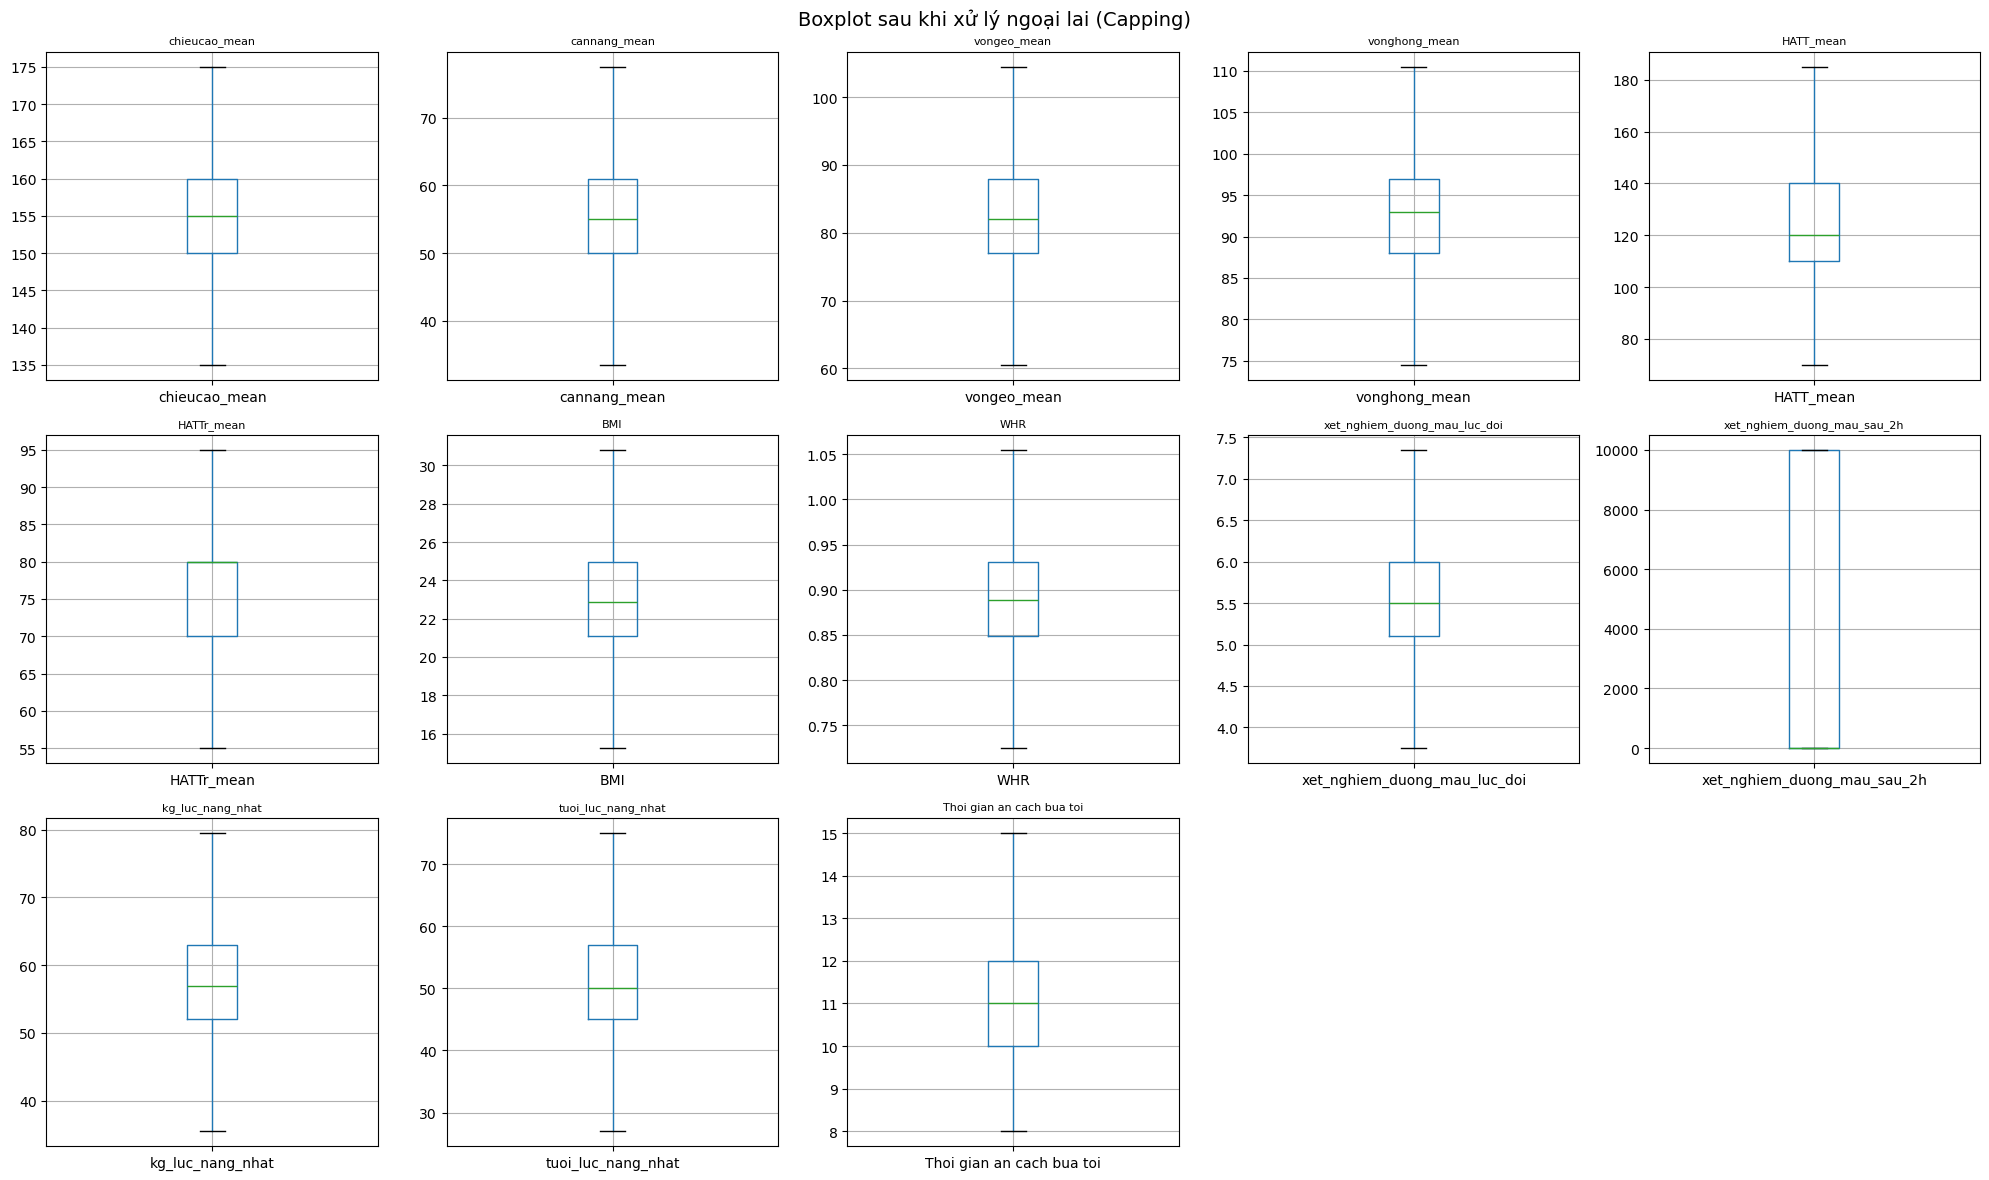

In [29]:
# ============================================================
# TRỰC QUAN HÓA SAU KHI XỬ LÝ NGOẠI LAI
# ============================================================
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    data.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=8)
for j in range(len(continuous_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot sau khi xử lý ngoại lai (Capping)', fontsize=14)
plt.tight_layout()
plt.show()

### Nhận xét

- Boxplot sau xử lý cho thấy biên giá trị đã ổn định hơn, ít điểm vượt ngưỡng cực đoan.
- Đây là kiểm tra trực quan để xác nhận bước capping hoạt động đúng.

## Bước 3: Feature Engineering
---

### Feature Creation
---

In [30]:
# One-Hot Encoding truoc Feature Creation
import pandas as pd

encoded_data = data.copy()

# Chon cac cot categorical dang object/category
cat_cols = encoded_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Khong one-hot cot nhan neu nhan dang object
for target_col in ['Diabetes', 'Diabetes_binary']:
    if target_col in cat_cols:
        cat_cols.remove(target_col)

if len(cat_cols) > 0:
    encoded_data = pd.get_dummies(encoded_data, columns=cat_cols, drop_first=False, dtype=int)

print('Da thuc hien One-Hot Encoding')
print('So cot categorical duoc ma hoa:', len(cat_cols))
print('Shape truoc ma hoa :', data.shape)
print('Shape sau ma hoa   :', encoded_data.shape)

Da thuc hien One-Hot Encoding
So cot categorical duoc ma hoa: 0
Shape truoc ma hoa : (12703, 63)
Shape sau ma hoa   : (12703, 63)


### Nhận xét

- One-hot encoding giúp đưa các biến phân loại về dạng số để mô hình học được.
- So sánh shape trước/sau mã hóa cho thấy mức tăng chiều dữ liệu và độ phức tạp đầu vào.

In [31]:
# Tao cac feature cong huong
fe_data = data.copy()
created_features = []

# Dam bao kieu so cho cac cot duoc dung trong interaction
numeric_candidates = [
    'Tuoi', 'BMI', 'WHR',
    'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h',
    'HATT_mean', 'HATTr_mean',
    'Ong/ba noi MÐTÐ', 'Bo/Me_MÐTÐ', 'Anh/chi/em MDTÐ', 'Con_MÐTÐ',
    'da_mang_thai_chua', 'co_bi_tieu_duong_thai_ki_khong'
]
for col in numeric_candidates:
    if col in fe_data.columns:
        fe_data[col] = pd.to_numeric(fe_data[col], errors='coerce')

# Dien khuyet tam thoi de tao feature tuong tac on dinh
for col in ['Tuoi', 'BMI', 'WHR', 'xet_nghiem_duong_mau_luc_doi', 'xet_nghiem_duong_mau_sau_2h', 'HATT_mean', 'HATTr_mean']:
    if col in fe_data.columns:
        fe_data[col] = fe_data[col].fillna(fe_data[col].median())

# Huyet ap
if 'HATT_mean' in fe_data.columns and 'HATTr_mean' in fe_data.columns:
    fe_data['PulsePressure'] = fe_data['HATT_mean'] - fe_data['HATTr_mean']
    fe_data['MAP'] = (2 * fe_data['HATTr_mean'] + fe_data['HATT_mean']) / 3
    created_features += ['PulsePressure', 'MAP']

# Ham tao interaction an toan
def add_interaction(new_col, col_a, col_b):
    if col_a in fe_data.columns and col_b in fe_data.columns:
        fe_data[new_col] = fe_data[col_a] * fe_data[col_b]
        created_features.append(new_col)

# Duong huyet + nhan trac
add_interaction('Glucose_BMI', 'xet_nghiem_duong_mau_luc_doi', 'BMI')
add_interaction('Glucose_WHR', 'xet_nghiem_duong_mau_luc_doi', 'WHR')
add_interaction('Post2h_BMI', 'xet_nghiem_duong_mau_sau_2h', 'BMI')

# Tuoi + nguy co chuyen hoa
add_interaction('Age_BMI', 'Tuoi', 'BMI')
add_interaction('Age_WHR', 'Tuoi', 'WHR')
add_interaction('Age_Glucose', 'Tuoi', 'xet_nghiem_duong_mau_luc_doi')

# Tien su gia dinh
family_cols = ['Ong/ba noi MÐTÐ', 'Bo/Me_MÐTÐ', 'Anh/chi/em MDTÐ', 'Con_MÐTÐ']
family_available = [c for c in family_cols if c in fe_data.columns]
if family_available:
    fe_data[family_available] = fe_data[family_available].fillna(0)
    fe_data['Family_DM_Score'] = fe_data[family_available].sum(axis=1)
    created_features.append('Family_DM_Score')
    add_interaction('Family_Glucose', 'Family_DM_Score', 'xet_nghiem_duong_mau_luc_doi')

# Tien su tieu duong thai ky
if 'da_mang_thai_chua' in fe_data.columns and 'co_bi_tieu_duong_thai_ki_khong' in fe_data.columns:
    fe_data['Gestational_Risk'] = (
        fe_data['da_mang_thai_chua'] * fe_data['co_bi_tieu_duong_thai_ki_khong']
    )
    created_features.append('Gestational_Risk')

print('So feature moi duoc tao:', len(created_features))
print('Danh sach feature moi:')
print(created_features)

So feature moi duoc tao: 11
Danh sach feature moi:
['PulsePressure', 'MAP', 'Glucose_BMI', 'Glucose_WHR', 'Post2h_BMI', 'Age_BMI', 'Age_WHR', 'Age_Glucose', 'Family_DM_Score', 'Family_Glucose', 'Gestational_Risk']


### Nhận xét

- Các feature tương tác mới bổ sung thông tin kết hợp giữa đường huyết, nhân trắc học và tiền sử.
- Danh sách feature tạo mới là căn cứ để đánh giá đóng góp của feature engineering.

In [62]:
# Xoa cac cot leakage duoc chon tu importance (giu lai 'dia')
leakage_remove_cols = [
    'xet_nghiem_duong_mau_luc_doi', 'glucose', 'fpg',
    'Glucose_class', 'Glucose_WHR', 'Family_Glucose',
    'Age_Glucose', 'Pre_diabete', 'Glucose_BMI',
    'prediabetes2', 'xet_nghiem_duong_mau_sau_2h', 'Post2h_BMI'
]

data_new = fe_data.drop(columns=leakage_remove_cols, errors='ignore').copy()

print('So cot ban dau (fe_data):', fe_data.shape[1])
print('So cot sau khi xoa leakage:', data_new.shape[1])
print("Con giu cot dia?:", 'dia' in data_new.columns)

So cot ban dau (fe_data): 74
So cot sau khi xoa leakage: 62
Con giu cot dia?: True


### Nhận xét

- Các biến có nguy cơ leakage đã được loại khỏi dữ liệu học để tránh mô hình học 'đáp án'.
- Việc vẫn giữ biến `dia` giúp duy trì tín hiệu lâm sàng quan trọng nhưng an toàn hơn.

In [51]:
# Tao X, y tu data_new (ket hop voi cac bien con lai)
X = data_new.drop(columns=['Diabetes'])
y = data_new['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Shape X:', X.shape)
print('So cot X:', X.shape[1])
print('Con cot dia trong X?:', 'dia' in X.columns)

Shape X: (12703, 61)
So cot X: 61
Con cot dia trong X?: True


### Nhận xét

- Bước tách `X, y` và chia train/test đã hoàn tất với `stratify`, nên tỉ lệ lớp được giữ ổn định.
- Đây là điểm bắt đầu hợp lệ trước khi chạy pipeline cuối và đánh giá mô hình.

## Final Clean Pipeline (Single Strategy)

Phuong an chot cho bai toan san loc:
- Mo hinh: RandomForest can bang lop (`class_weight='balanced'`)
- Nguong phan loai: `threshold = 0.45`
- Muc tieu nghiep vu: uu tien Recall de giam bo sot ca benh

### Step 1 - Chuan bi du lieu

Tao tap du lieu modeling cuoi cung tu `data_new`, sau do tach train/test voi `stratify=y_final` de giu nguyen ti le lop.

In [77]:
# Step 1: Chuan bi du lieu va tach train/test
final_df = data_new.copy()
X_final = final_df.drop(columns=['Diabetes'])
y_final = final_df['Diabetes']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, test_size=0.3, random_state=42, stratify=y_final
)

print('Shape tong du lieu:', final_df.shape)
print('Shape X:', X_final.shape)
print('Ty le lop 1 (toan bo):', round(y_final.mean(), 4))
print('Train/Test size:', len(y_train_f), '/', len(y_test_f))

Shape tong du lieu: (12703, 62)
Shape X: (12703, 61)
Ty le lop 1 (toan bo): 0.1257
Train/Test size: 8892 / 3811


**Nhan xet**
- Du lieu cuoi cung co `12703` dong va `62` cot; phan feature la `61` cot.
- Ty le lop 1 la `0.1257` (mat can bang lop ro rang).
- Train/Test la `8892/3811`, phu hop voi ty le chia `70/30`.

### Step 2 - Preprocess an toan

Thuc hien imputation tren train roi ap dung cho test, sau do one-hot encoding va canh cot train/test de tranh leakage.

In [78]:
from sklearn.impute import SimpleImputer

# Step 2: Preprocess an toan
num_cols_f = X_train_f.select_dtypes(include=['number']).columns.tolist()
cat_cols_f = X_train_f.select_dtypes(exclude=['number']).columns.tolist()

X_train_proc = X_train_f.copy()
X_test_proc = X_test_f.copy()

if num_cols_f:
    imp_num = SimpleImputer(strategy='median')
    X_train_proc[num_cols_f] = imp_num.fit_transform(X_train_proc[num_cols_f])
    X_test_proc[num_cols_f] = imp_num.transform(X_test_proc[num_cols_f])

if cat_cols_f:
    imp_cat = SimpleImputer(strategy='most_frequent')
    X_train_proc[cat_cols_f] = imp_cat.fit_transform(X_train_proc[cat_cols_f])
    X_test_proc[cat_cols_f] = imp_cat.transform(X_test_proc[cat_cols_f])

X_train_proc = pd.get_dummies(X_train_proc, columns=cat_cols_f, drop_first=False, dtype=int)
X_test_proc = pd.get_dummies(X_test_proc, columns=cat_cols_f, drop_first=False, dtype=int)
X_test_proc = X_test_proc.reindex(columns=X_train_proc.columns, fill_value=0)

print('So cot numeric:', len(num_cols_f))
print('So cot categorical:', len(cat_cols_f))
print('Shape sau preprocess train/test:', X_train_proc.shape, X_test_proc.shape)

So cot numeric: 61
So cot categorical: 0
Shape sau preprocess train/test: (8892, 61) (3811, 61)


**Nhan xet**
- So cot numeric: `61`, so cot categorical: `0`.
- Shape sau preprocess la `(8892, 61)` va `(3811, 61)` => train/test dong bo cot, san sang cho model.

### Step 3 - Train Balanced RF (threshold mac dinh 0.50)

Huấn luyện RandomForest với `class_weight='balanced'` để xử lý mất cân bằng lớp ở pha học.

In [79]:
# Step 3: Train model balanced
final_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    max_features=4,
    min_samples_leaf=1,
    min_samples_split=2,
    criterion='entropy',
    class_weight='balanced',
    random_state=42
)

final_model.fit(X_train_proc, y_train_f)
y_prob_f = final_model.predict_proba(X_test_proc)[:, 1]
y_pred_05 = (y_prob_f >= 0.5).astype(int)

summary_05 = pd.DataFrame([{
    'Model': 'Balanced RF @0.50',
    'Accuracy': accuracy_score(y_test_f, y_pred_05),
    'Precision': precision_score(y_test_f, y_pred_05, zero_division=0),
    'Recall': recall_score(y_test_f, y_pred_05, zero_division=0),
    'F1': f1_score(y_test_f, y_pred_05, zero_division=0)
}])

print(summary_05.round(4))

               Model  Accuracy  Precision  Recall      F1
0  Balanced RF @0.50    0.9297     0.7279  0.7035  0.7155


**Nhan xet**
- Tai nguong `0.50`, mo hinh dat: Accuracy `0.9297`, Precision `0.7279`, Recall `0.7035`, F1 `0.7155`.
- Day la moc baseline tot truoc khi chon nguong theo muc tieu nghiep vu (uu tien Recall).

### Step 4 - Bao cao ket qua cuoi (threshold = 0.45)

Ap dung nguong co dinh `0.45` de tang kha nang bat duoc ca benh (tang Recall lop 1).

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Tinh metric cho hai tap du lieu

y_pred_train_final = final_model.predict(X_train_proc)
y_pred_test_final = y_pred_final

final_result = pd.DataFrame(
    {
        "Recall": [
            recall_score(y_test_f, y_pred_test_final, zero_division=0),
            recall_score(y_train_f, y_pred_train_final, zero_division=0),
        ],
        "Precision": [
            precision_score(y_test_f, y_pred_test_final, zero_division=0),
            precision_score(y_train_f, y_pred_train_final, zero_division=0),
        ],
        "F1 Score": [
            f1_score(y_test_f, y_pred_test_final, zero_division=0),
            f1_score(y_train_f, y_pred_train_final, zero_division=0),
        ],
        "Accuracy": [
            accuracy_score(y_test_f, y_pred_test_final),
            accuracy_score(y_train_f, y_pred_train_final),
        ],
    },
    index=["Test", "Train"],
)

final_result.round(6)

,Recall,Precision,F1 Score,Accuracy
Test,0.766180,0.478488,0.589085,0.865652
Train,0.822004,0.810406,0.816163,0.953441


**Nhan xet**
- Test: Recall `0.7662`, Precision `0.4785`, F1 `0.5891`, Accuracy `0.8657`.
- Train: Recall `0.8220`, Precision `0.8104`, F1 `0.8162`, Accuracy `0.9534`.
- So voi threshold `0.50`, Recall test tang ro rang, dung voi muc tieu "it bo sot ca benh".
- Trade-off ky vong: Precision giam, doi lai model nhay hon voi ca duong tinh.

### Tong ket nghiep vu

Trong bai toan san loc tieu duong, chi so can uu tien la Recall vi false negative (bo sot ca benh) thuong nguy hiem hon false positive (canh bao nham). Vi vay, viec dat nguong `0.45` la hop ly cho muc tieu giam bo sot.